# Chua's Circuit: part 3
We will try using a better dataset with more data points, as the electric circuit is easily measurable

In [1]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr
import pysindy as ps 

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

# Dataset

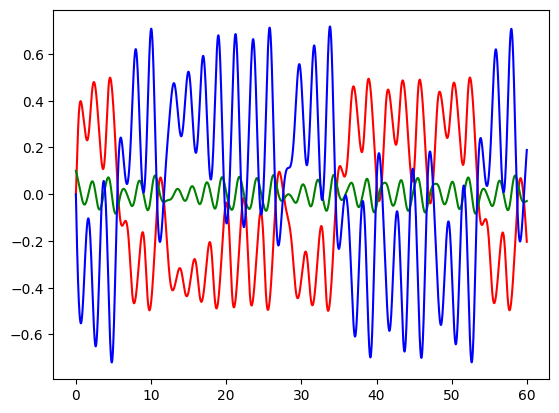

In [2]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 60

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0.0001, 0.1, 0))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

plt.plot(sol.ts, sol.ys[:, 0], color='r')
plt.plot(sol.ts, sol.ys[:, 1], color='g')
plt.plot(sol.ts, sol.ys[:, 2], color='b')


In [3]:
T_MAX = 60
@jax.jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.05))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_train = sol_train.ys[::5]
    t_train = sol_train.ts[::5]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+T_MAX*0.5, 0.1))
    y0 = jnp.array((0.0001, 0.1, 0.1))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+T_MAX*0.5, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_val = sol_val.ys[::2]
    t_val = sol_val.ts[::2]

    return x_train, t_train, x_val, t_val, sol_train, sol_val

In [4]:
x_train, t_train, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


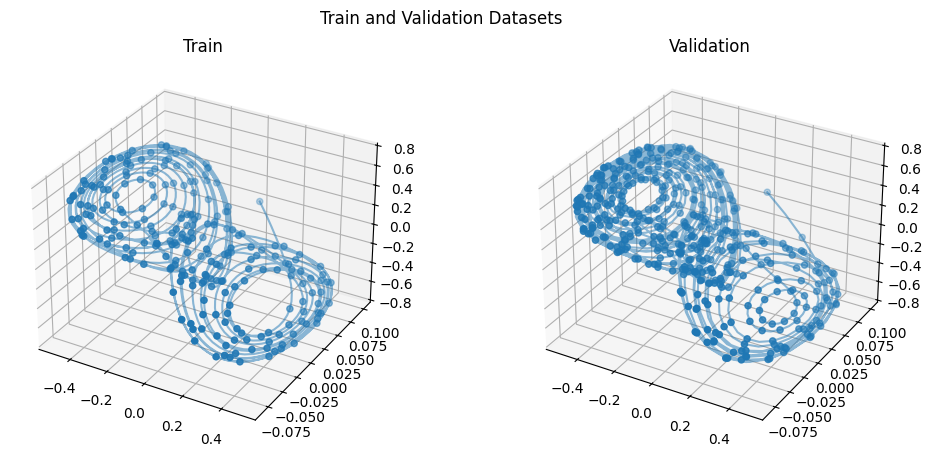

In [420]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(projection='3d'))

axes[0].plot(sol_train.ys[:, 0],sol_train.ys[:, 1],sol_train.ys[:, 2],alpha=0.5)
axes[0].scatter(x_train[:, 0],x_train[:, 1],x_train[:, 2],)

axes[1].plot(sol_val.ys[:, 0],sol_val.ys[:, 1],sol_val.ys[:, 2], alpha=0.5)
axes[1].scatter(x_val[:, 0],x_val[:, 1],x_val[:, 2],)

axes[0].set_title("Train")
axes[1].set_title("Validation")

plt.suptitle("Train and Validation Datasets")

plt.show()

# Model
We use the UDE PEM x

In [5]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

In [6]:
class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [7]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array

    def __init__(self, alpha, beta, gamma, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def __call__(self, t, state, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state, obs_fun)


# Training

In [84]:
def solve_ude_light_pem(model, y0, ts, obs_fun):
    term = dfx.ODETerm(model)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-7, atol=1e-8)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper,
        args=obs_fun,
        max_steps=10000
    )
    return sol.ys


@eqx.filter_value_and_grad
def loss_fn_pem(model, x0, y_true, ts, obs_fun):
    # calculate loss
    pred = solve_ude_light_pem(model, x0, ts, obs_fun)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step_pem(model, opt_state, x0, x_true, ts, optimizer, obs_fun):
    # one train step on the dataset
    loss, grads = loss_fn_pem(model, x0, x_true, ts, obs_fun)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [86]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

linear_interp_val = LinearInterpolator(t_val, x_val)
linear_interp_jit_val = eqx.filter_jit(linear_interp_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    ude_pem, opt_state, loss = train_step_pem(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp_jit)

    val_loss = None

    train_losses_pem.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn_pem(ude_pem, x_val[0], x_val, t_val, linear_interp_jit_val)[0]
        val_losses_pem.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	1.3997e-02	1.3674e-02
1	1.5439e-02	---
2	1.3908e-02	---
3	1.4517e-02	---
4	1.4637e-02	---
5	1.4071e-02	---
6	1.3718e-02	---
7	1.3833e-02	---
8	1.4020e-02	---
9	1.3929e-02	---
10	1.3683e-02	---
11	1.3506e-02	---
12	1.3473e-02	---
13	1.3509e-02	---
14	1.3499e-02	---
15	1.3394e-02	---
16	1.3243e-02	---
17	1.3138e-02	---
18	1.3131e-02	---
19	1.3135e-02	---
20	1.3014e-02	---
21	1.2872e-02	---
22	1.2813e-02	---
23	1.2800e-02	---
24	1.2740e-02	---
25	1.2629e-02	---
26	1.2555e-02	---
27	1.2525e-02	---
28	1.2466e-02	---
29	1.2359e-02	---
30	1.2279e-02	---
31	1.2246e-02	---
32	1.2184e-02	---
33	1.2086e-02	---
34	1.2024e-02	---
35	1.1969e-02	---
36	1.1867e-02	---
37	1.1773e-02	---
38	1.1701e-02	---
39	1.1597e-02	---
40	1.1472e-02	---
41	1.1363e-02	---
42	1.1231e-02	---
43	1.1066e-02	---
44	1.0907e-02	---
45	1.0713e-02	---
46	1.0481e-02	---
47	1.0226e-02	---
48	9.9175e-03	---
49	9.5619e-03	---
50	9.1444e-03	---
51	8.6462e-03	---
52	8.0877e-03	---
53	7.4325e-03	---
54	6.6548e-03	---
55	5.7578e-03

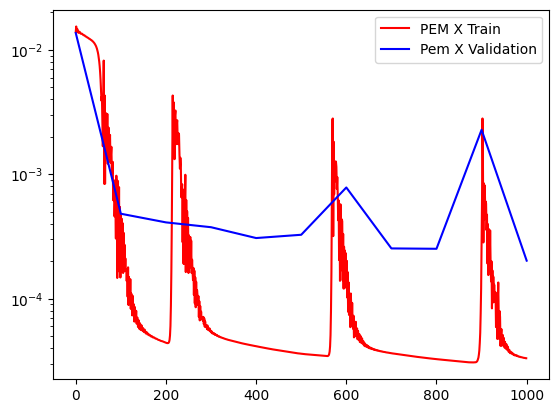

In [87]:
plt.semilogy(range(0, len(train_losses_pem)), train_losses_pem, color='red', label="PEM X Train")
plt.semilogy(100*jnp.array(range(len(val_losses_pem))), val_losses_pem, color='blue', label="Pem X Validation")

plt.legend()
plt.show()

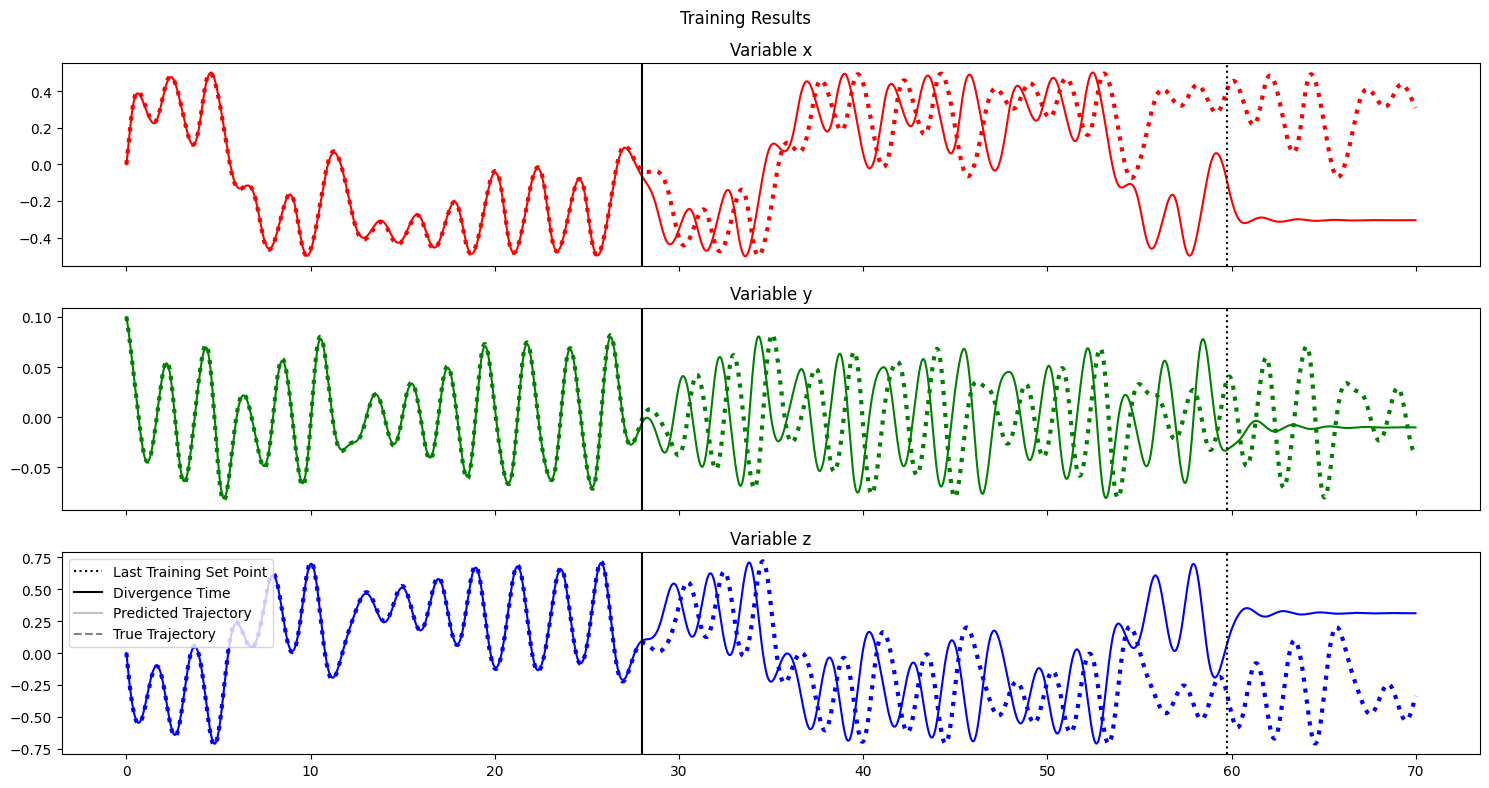

In [88]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 70

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=linear_interp_jit, saveat=saveat, stepsize_controller=stepper, max_steps=10000).ys

N = 28

for i in range(3):
    plt.sca(axes[i])
    plt.plot(t_eval, traj_final[:, i], color=col_dict[i],)
    plt.plot(t_eval, traj_true[:, i], color=col_dict[i], linestyle=':', linewidth=3)
    plt.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")
    plt.title(f"Variable {var_dict[i]}")
    plt.axvline(N, color="k", label="Divergence Time")

plt.plot([], [], color="gray", alpha=0.5, label="Predicted Trajectory")
plt.plot([], [], color="gray", linestyle="--", label="True Trajectory")

plt.legend()
plt.suptitle("Training Results")
plt.tight_layout()
plt.show()

In [89]:
# Calculate the differences and (try to) estimate Lyapunov coefficients

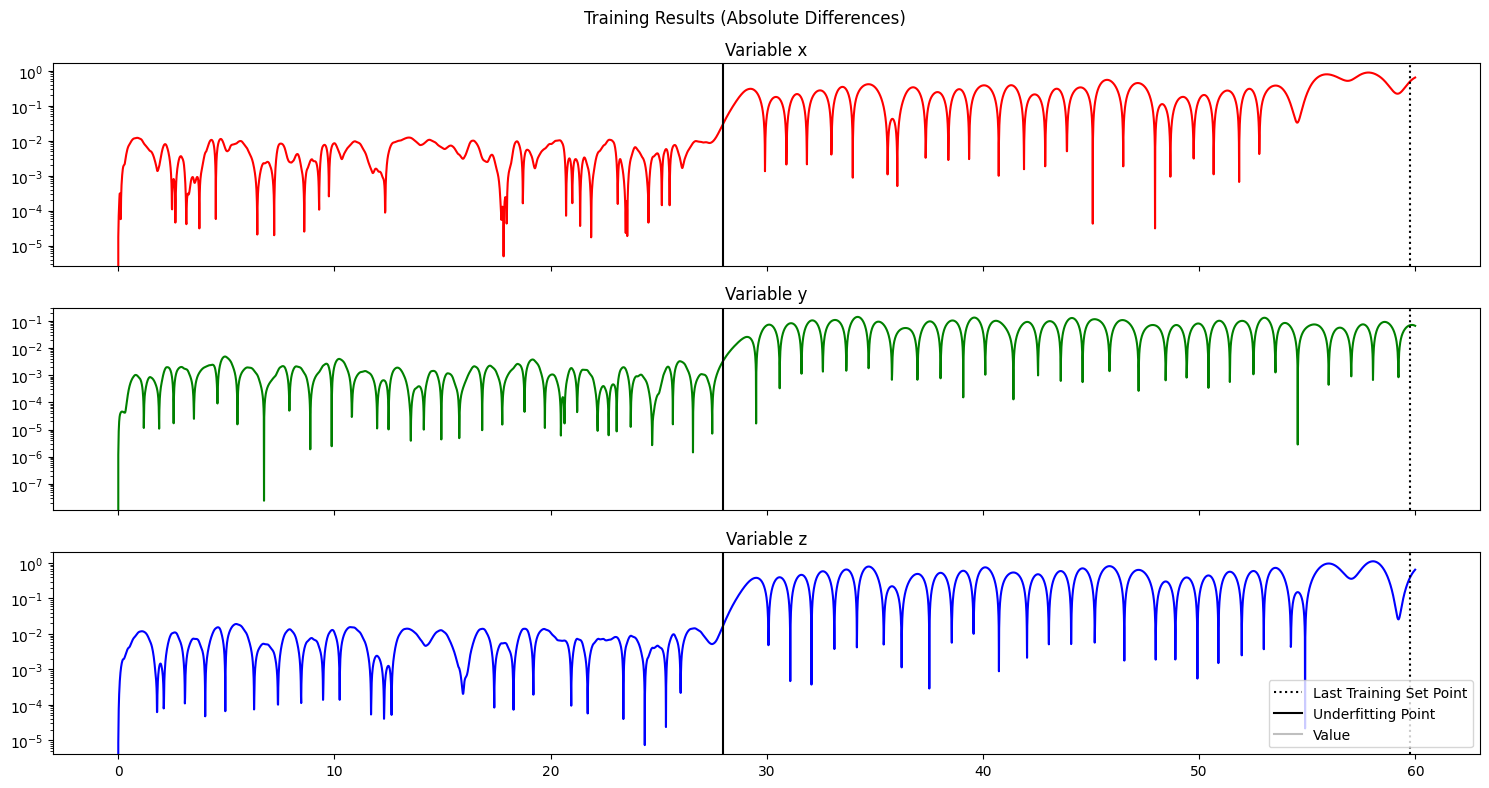

In [90]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 60

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=linear_interp_jit, saveat=saveat, stepsize_controller=stepper, max_steps=10000).ys

N = 28

for i in range(3):
    plt.sca(axes[i])
    plt.semilogy(t_eval, jnp.abs(traj_final[:, i]-traj_true[:, i]), color=col_dict[i],)
    plt.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")
    plt.title(f"Variable {var_dict[i]}")
    plt.axvline(N, color="k", label="Underfitting Point")

plt.plot([], [], color="gray", alpha=0.5, label="Value")

plt.legend()
plt.suptitle("Training Results (Absolute Differences)")
plt.tight_layout()
plt.show()

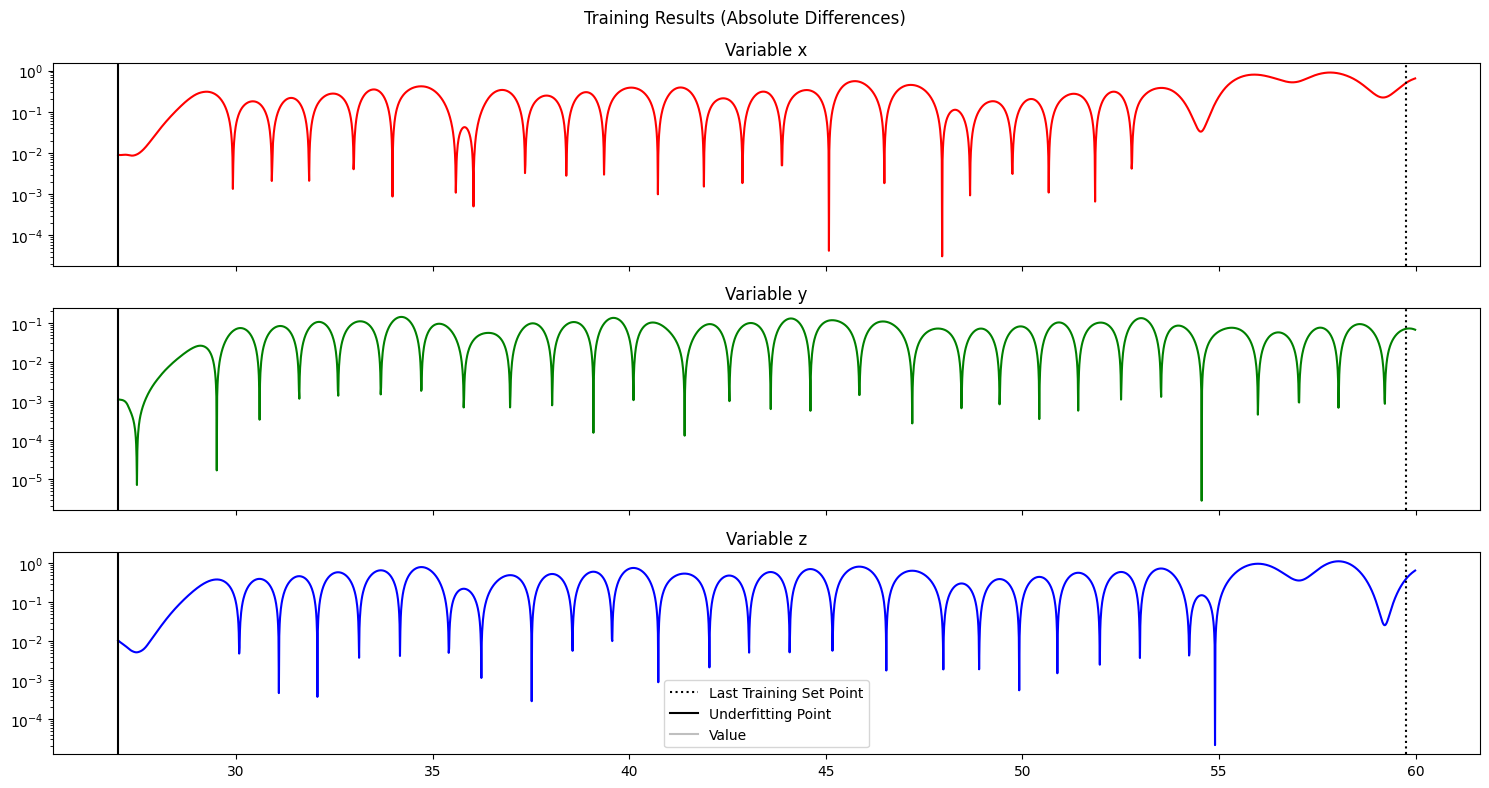

In [91]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 60
N = 27

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(N, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=linear_interp_jit, saveat=saveat, stepsize_controller=stepper, max_steps=10000).ys


for i in range(3):
    plt.sca(axes[i])
    plt.semilogy(t_eval, jnp.abs(traj_final[:, i]-traj_true[:, i]), color=col_dict[i],)
    plt.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")
    plt.title(f"Variable {var_dict[i]}")
    plt.axvline(N, color="k", label="Underfitting Point")

plt.plot([], [], color="gray", alpha=0.5, label="Value")

plt.legend()
plt.suptitle("Training Results (Absolute Differences)")
plt.tight_layout()
plt.show()

In [ ]:
eqx.tree_serialise_leaves("./models_weights/31_5_ude_jax.eqx", ude_pem)


## Model extrapolation 

### 1. Plot learned network and compare to the real polynomial

In [9]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)

linear_interp_val = LinearInterpolator(t_val, x_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

ude_pem = eqx.tree_deserialise_leaves("./models_weights/31_5_ude_jax.eqx", ude_pem)

In [11]:
# plot learned network
y_hats = []
ys = []
for x in (x_space:=jnp.arange(-1, 1, 0.01)):
    y_hat = ude_pem.net(x)
    y_hats.append(y_hat)
    ys.append(A*x**3 + C*x)


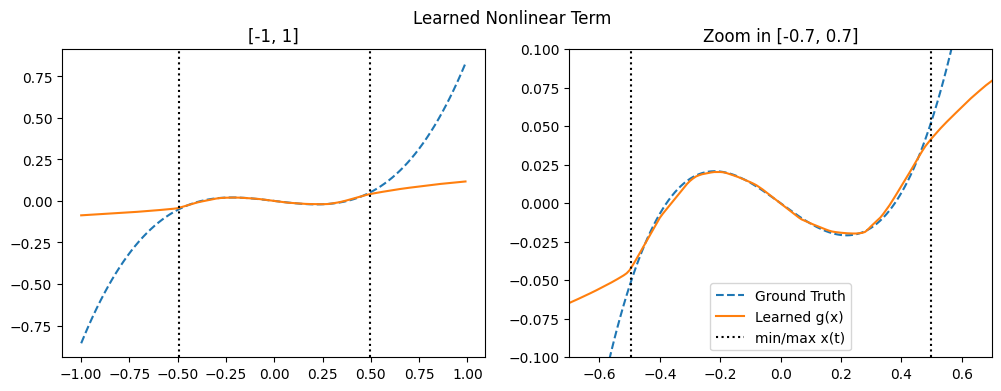

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plt.sca(axes[0])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, y_hats, label="Learned g(x)")
plt.axvline(x_train[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.title("[-1, 1]")

plt.sca(axes[1])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, y_hats, label="Learned g(x)")
plt.axvline(x_train[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.xlim(-0.7, 0.7)
plt.ylim(-0.1, 0.1)
plt.title("Zoom in [-0.7, 0.7]")

plt.legend()
plt.suptitle("Learned Nonlinear Term")

plt.show()

In [102]:
import jax.numpy as jnp
import numpy as np

data = np.genfromtxt(
    "./losses/31_5_losses.txt",
    delimiter="\t",     
    missing_values="---", # set --- as NaN
    filling_values=np.nan
)

data_jax = jnp.array(data)
clean_rows = data_jax[~jnp.isnan(data_jax).any(axis=1)]

In [105]:
clean_rows

Array([[0.0000e+00, 1.3997e-02, 1.3674e-02],
       [1.0000e+02, 4.6962e-04, 4.8216e-04],
       [2.0000e+02, 4.4265e-05, 4.1085e-04],
       [3.0000e+02, 5.4826e-05, 3.7571e-04],
       [4.0000e+02, 4.1510e-05, 3.0744e-04],
       [5.0000e+02, 3.6114e-05, 3.2667e-04],
       [6.0000e+02, 1.2457e-04, 7.8398e-04],
       [7.0000e+02, 3.6434e-05, 2.5375e-04],
       [8.0000e+02, 3.2668e-05, 2.5201e-04],
       [9.0000e+02, 2.6585e-04, 2.2808e-03],
       [9.9900e+02, 3.3226e-05, 2.0230e-04]], dtype=float64)

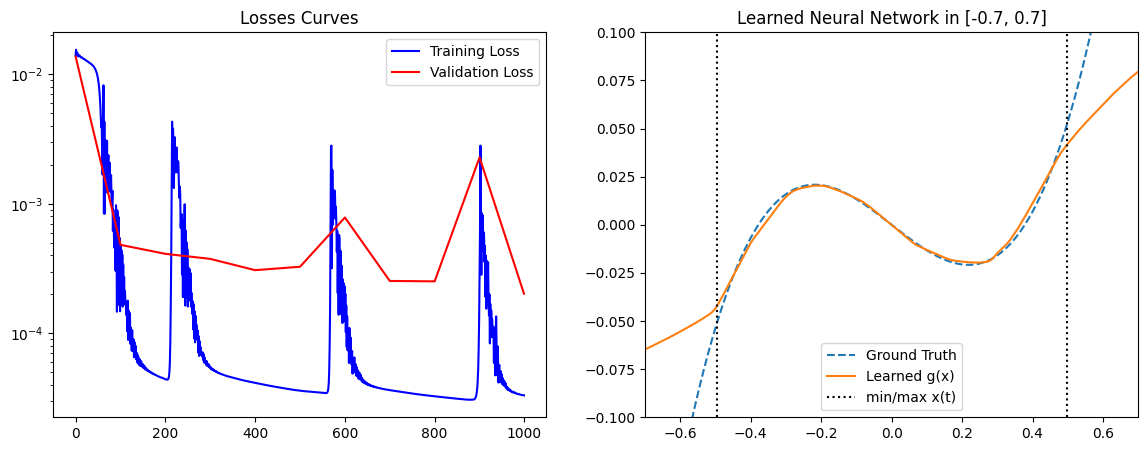

In [114]:
# Thesis purposes: plot, at left, the losses curve and on the right the learned trajectories

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
plt.semilogy(data_jax[:, 0], data_jax[:, 1], label="Training Loss", color='blue')
plt.semilogy(clean_rows[:, 0], clean_rows[:, 2], label="Validation Loss", color="red")
plt.title("Losses Curves")
plt.legend()

plt.sca(axes[1])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, y_hats, label="Learned g(x)")
plt.axvline(x_train[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.xlim(-0.7, 0.7)
plt.ylim(-0.1, 0.1)
plt.title("Learned Neural Network in [-0.7, 0.7]")
plt.legend()

plt.show()


Very similar in its "data range". However shows poor generalization

### 2. Use SINDy

Remember
$$
\begin{align}
\dot x &= 10y-10x^3+1.43x \\
\dot y &= x-y+z \\
\dot z &= -16 y
\end{align}
$$

In [263]:
sindy_baseline = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.STLSQ(max_iter=1000000, threshold=0.7, verbose=True)
)

sindy_baseline.fit(x_train, t_train, feature_names=['x', 'y', 'z'])


sindy_baseline.print()

 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 5.7947e+00 ... 1.0456e+01 ...         10 ... 1.6251e+01
         1 ... 2.7296e+00 ... 1.1467e+01 ...          9 ... 1.4197e+01
         2 ... 2.6216e+00 ... 1.1572e+01 ...          9 ... 1.4194e+01
(x)' =  1.428 x +  9.575 y + -14.769 x^3 + -8.115 x^2 z + -3.190 x z^2
(y)' =  0.900 x + -0.911 y +  0.903 z
(z)' = -14.709 y


In [264]:
# Train with PEM
X_dot = jnp.zeros_like(x_train)

for i, (t, x) in enumerate(zip(t_train, x_train)):
    X_dot = X_dot.at[i, :].set(ude_pem(t, x, linear_interp_jit))

sindy_ude = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.STLSQ(max_iter=1000000, threshold=0.70, verbose=True)
)

sindy_ude.fit(x_train, t_train, feature_names=['x', 'y', 'z'], x_dot=X_dot )

sindy_ude.print()

 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 9.9752e+00 ... 1.1955e+01 ...         13 ... 2.1930e+01
         1 ... 3.0968e+00 ... 1.3187e+01 ...         12 ... 1.6284e+01
         2 ... 2.7452e+00 ... 1.3250e+01 ...         11 ... 1.5995e+01
         3 ... 2.6009e+00 ... 1.3388e+01 ...         11 ... 1.5989e+01
(x)' =  1.340 x +  10.077 y + -11.683 x^3 + -3.846 x^2 z + -1.619 x z^2
(y)' =  1.000 x + -1.000 y +  1.000 z
(z)' = -16.000 y


In [265]:
t_train_new = jnp.arange(0, N:=28, 0.01) # N is the part where the model starts underfitting badly
x_train_new = solve_ude_light_pem(ude_pem, x_train[0], t_train_new, linear_interp_jit)

X_dot = jnp.zeros_like(x_train_new)

for i, (t, x) in enumerate(zip(t_train_new, x_train_new)):
    X_dot = X_dot.at[i, :].set(ude_pem(t, x, linear_interp_jit))



In [293]:
sindy_ude_alt = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.STLSQ(max_iter=1000000,threshold=0.9, verbose=True)
)

sindy_ude_alt.fit(x_train_new, t_train_new, feature_names=['x', 'y', 'z'], x_dot=X_dot)

sindy_ude_alt.print()

 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 4.2536e+00 ... 1.8385e+01 ...          8 ... 2.2639e+01
         1 ... 2.4790e+00 ... 1.9107e+01 ...          8 ... 2.1586e+01
(x)' =  1.302 x +  9.947 y + -9.084 x^3 +  0.179 x^2 z
(y)' =  1.003 x + -1.015 y +  1.003 z
(z)' = -16.023 y


SUPER close! The only "hindrance" is the extra x^2 z term... let's see how it influences our final model

### 3. Evaluate SINDy models

particularly difficult as the model is chaotic

In [13]:
"""
(x)' =  1.340 x +  10.077 y + -11.683 x^3 + -3.846 x^2 z + -1.619 x z^2
(y)' =  1.000 x + -1.000 y +  1.000 z
(z)' = -16.000 y

"""

def learned_sindy_model1(t, xyz, args):
    x,y,z=xyz
    return jnp.array(
        [
            1.302 * x + 9.947 * y - 9.084 * (x**3) + 0.179 * (x**2) * z, 
            1.003 * x - 1.015 * y + 1.003 * z,
            -16.023 * y
        ]
    )

def learned_sindy_model2(t, xyz, args):
    x,y,z=xyz
    return jnp.array(
        [
            1.34 * x + 10.077 * y - 11.683 * (x**3) - 3.846 * (x**2) * z - 1.619 * x * (z**2),
            x - y + z,
            -16 * y
        ]
    )

def learned_sindy_model3(t, xyz, args):
    x, y, z = xyz

    return jnp.array([
        1.428 * x + 9.575 * y - 14.769 * x**3
            - 8.115 * x**2 * z
            - 3.190 * x * z**2,
        0.900 * x - 0.911 * y + 0.903 * z,
        -14.709 * y
    ])

# 1: SINDy on UDE, from 0 to 28
# 2: SINDy on UDE, all 
# 3: Baseline SINDy

In [14]:
term = dfx.ODETerm(chua_model)
term_sindy = dfx.ODETerm(learned_sindy_model1)
term_sindy2 = dfx.ODETerm(learned_sindy_model2)
term_sindy3 = dfx.ODETerm(learned_sindy_model3)

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

sol = dfx.diffeqsolve(
    term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper
    )
traj_true = sol.ys

traj_sindy1 = dfx.diffeqsolve(
    term_sindy, 
    solver, 
    t0=0, t1=T_MAX, dt0=0.01, 
    y0=y0, 
    saveat=saveat, 
    stepsize_controller=stepper,
    ).ys

traj_sindy2 = dfx.diffeqsolve(
    term_sindy2, 
    solver, 
    t0=0, t1=T_MAX, dt0=0.01, 
    y0=y0, 
    saveat=saveat, 
    stepsize_controller=stepper,
    ).ys

traj_sindy3 = dfx.diffeqsolve(
    term_sindy3, 
    solver, 
    t0=0, t1=T_MAX, dt0=0.01, 
    y0=y0, 
    saveat=saveat, 
    stepsize_controller=stepper,
    ).ys


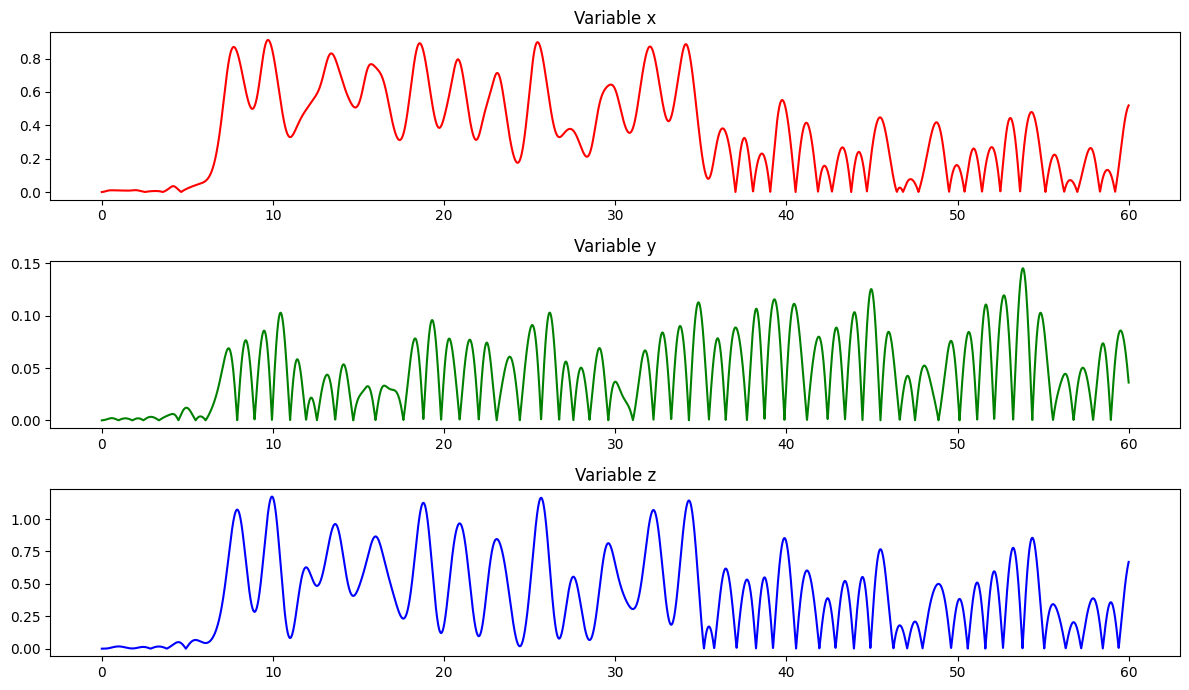

In [15]:
# plot logarithmic differences
fig, axes = plt.subplots(3, 1, figsize=(12, 7))

for i in range(3):
    plt.sca(axes[i])
    plt.plot(t_eval, jnp.abs(traj_true[: , i]-traj_sindy1[:, i]), color=col_dict[i])
    plt.title(f"Variable {var_dict[i]}")
    
plt.tight_layout()

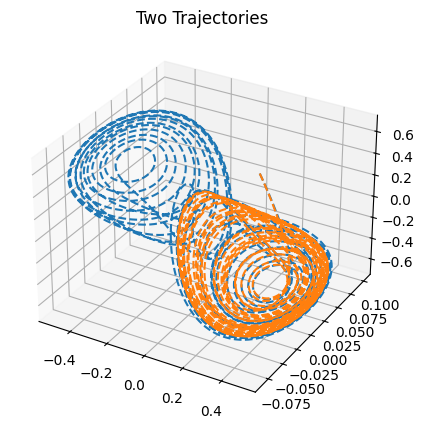

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5), subplot_kw=dict(projection='3d'))

ax.plot(traj_true[:, 0],traj_true[:, 1],traj_true[:, 2], alpha=1, linestyle='--', label="Ground Truth" )
ax.plot(traj_sindy1[:, 0],traj_sindy1[:, 1],traj_sindy1[:, 2], alpha=1, linestyle='--', label="SINDy-learned Trajectory")

ax.set_title("Two Trajectories")

plt.show()





In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import Normalize

# Compute relative error
eps = 1e-12

error = jnp.linalg.norm(traj_true - traj_sindy, axis=1)

# Coordinates
x = traj_true[:,0]
y = traj_true[:,1]
z = traj_true[:,2]

# Build line segments
points = jnp.array([x, y, z]).T.reshape(-1,1,3)
segments = jnp.concatenate([points[:-1], points[1:]], axis=1)

# normalize stuff
norm = Normalize(vmin=jnp.min(error), vmax=jnp.max(error))

# line
lc = Line3DCollection(
    segments,
    cmap='inferno',
    norm=norm
)

lc.set_array(error[:-1])
lc.set_linewidth(1.5)

# Figure
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.add_collection3d(lc)

# Axis limits
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_zlim(z.min(), z.max())

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.set_title('Absolute errors of fit')

# Colorbar
cbar = fig.colorbar(lc, ax=ax, pad=0.1)
cbar.set_label('Absolute Error')

plt.show()

NameError: name 'traj_sindy' is not defined

In [25]:
## Unite two plots above into one

def show_trajectory_results(traj_true, traj_sindy, name):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), subplot_kw=dict(projection='3d'))


    axes[0].plot(traj_true[:, 0],traj_true[:, 1],traj_true[:, 2], alpha=1, linestyle='--', label="Ground Truth" )
    axes[0].plot(traj_sindy[:, 0],traj_sindy[:, 1],traj_sindy[:, 2], alpha=1, label="SINDy-learned Trajectory")

    axes[0].set_title("Two Trajectories")

    axes[0].legend()

    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_zlabel("z")

    # Second figure
    # Compute relative error
    eps = 1e-12
    error = jnp.linalg.norm(traj_true - traj_sindy, axis=1)

    # Coordinates
    x = traj_true[:,0]
    y = traj_true[:,1]
    z = traj_true[:,2]

    # Build line segments
    points = jnp.array([x, y, z]).T.reshape(-1,1,3)
    segments = jnp.concatenate([points[:-1], points[1:]], axis=1)

    # normalize stuff
    norm = Normalize(vmin=jnp.min(error), vmax=jnp.max(error))

    # line
    lc = Line3DCollection(
        segments,
        cmap='inferno',
        norm=norm
    )

    lc.set_array(error[:-1])
    lc.set_linewidth(1.5)

    # Figure
    axes[1].add_collection3d(lc)

    # Axis limits
    axes[1].set_xlim(x.min(), x.max())
    axes[1].set_ylim(y.min(), y.max())
    axes[1].set_zlim(z.min(), z.max())

    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].set_zlabel('z')

    axes[1].set_title('Absolute errors of fit')

    # Colorbar
    cbar = fig.colorbar(lc, ax=axes[1], pad=0.1)
    cbar.set_label('Absolute Error')

    plt.suptitle(name)

    plt.show()

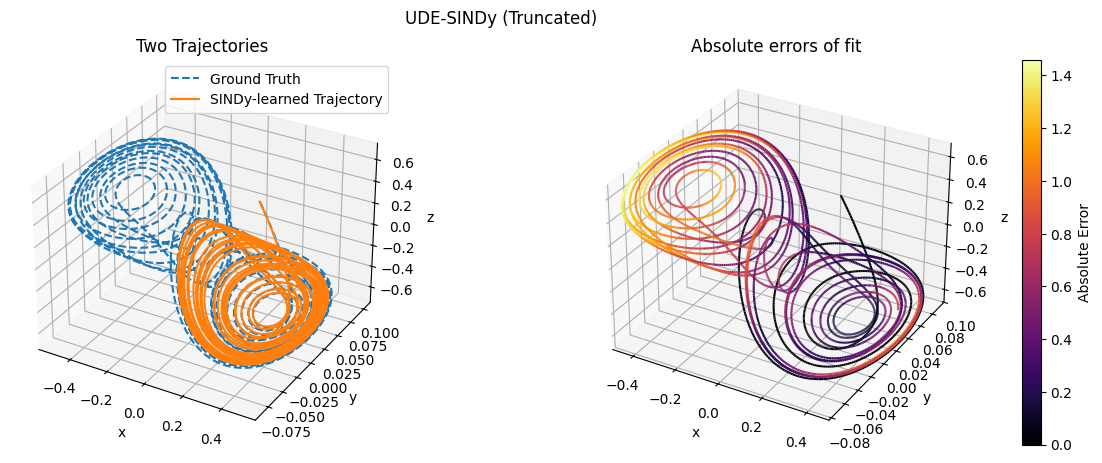

In [415]:
show_trajectory_results(traj_true, traj_sindy1, "UDE-SINDy (Truncated)") # UDE-SINDy limited 

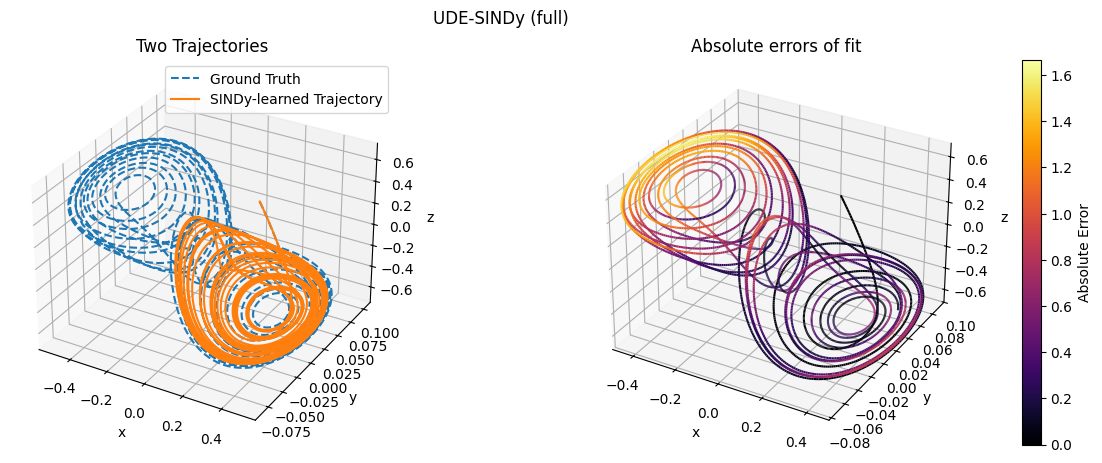

In [416]:
show_trajectory_results(traj_true, traj_sindy2, "UDE-SINDy (full)") # UDE-SINDy full

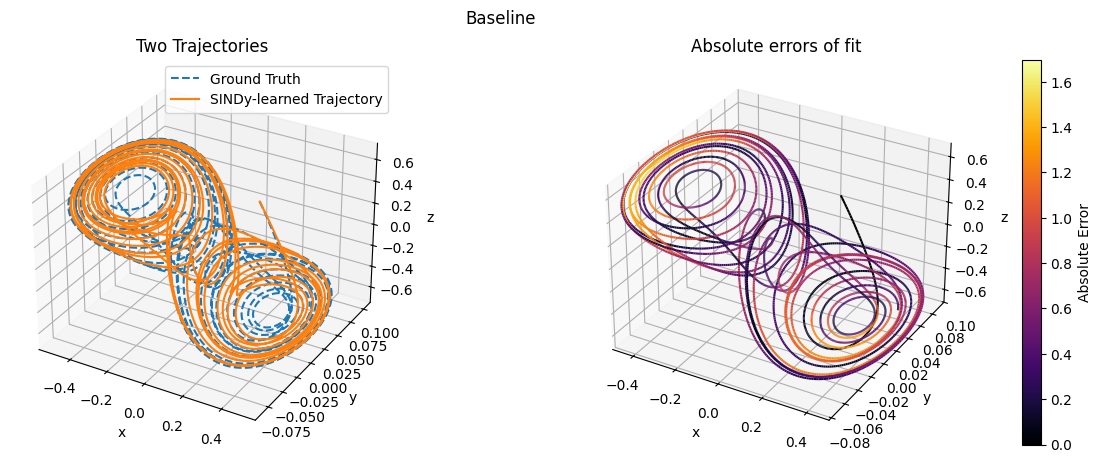

In [417]:
show_trajectory_results(traj_true, traj_sindy3, "Baseline") # Baseline

In [254]:
# Idea: estimate the probability distributions with Scikit learn


In [418]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(kernel="gaussian").fit(traj_true)
base_likelihood = kde.score_samples(traj_true).sum()

loss1 = base_likelihood - kde.score_samples(traj_sindy1).sum()
loss2 = base_likelihood - kde.score_samples(traj_sindy2).sum()
loss3 = base_likelihood - kde.score_samples(traj_sindy3).sum()

print(f"LOSSES (Nats):\n\tBaseline: {loss3}\n\tUDE (All data): {loss2}\n\tUDE (0 to 28): {loss1}")

LOSSES (Nats):
	Baseline: 38.77587226963078
	UDE (All data): -44.21679208144269
	UDE (0 to 28): -21.8574832258455


In [262]:
# Idea: calculate MSE of coefficients directly

In [267]:
features = sindy_baseline.get_feature_names()

In [281]:
import numpy as np 
np.where(np.array(features) == 'x^3')[0]

# find where is x^3

array([9])

In [294]:
chua_coef = jnp.zeros((3, len(features)))

chua_coef = chua_coef.at[0, 0:2].set(jnp.array([1.43, 10]))
chua_coef = chua_coef.at[0, 9].set(-10)

chua_coef = chua_coef.at[1, 0:3].set(jnp.array([1, -1, 1]))

chua_coef = chua_coef.at[2, 1].set(-16)

chua_coef

Array([[  1.43,  10.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  , -10.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ],
       [  1.  ,  -1.  ,   1.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,
          0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ],
      

In [295]:
from sklearn.metrics import mean_squared_error
print("MSE ERRORS FROM THE TRUE MODEL (COEFFICIENTS)")

print(f"\tBASELINE: {mean_squared_error(chua_coef, sindy_baseline.optimizer.coef_) }")
print(f"\tUDE (FULL): {mean_squared_error(chua_coef, sindy_ude.optimizer.coef_) }")
print(f"\tUDE (LIMITED): {mean_squared_error(chua_coef, sindy_ude_alt.optimizer.coef_) }")


MSE ERRORS FROM THE TRUE MODEL (COEFFICIENTS)
	BASELINE: 0.6100043825038686
	UDE (FULL): 0.1227887753682183
	UDE (LIMITED): 0.005401500915410498


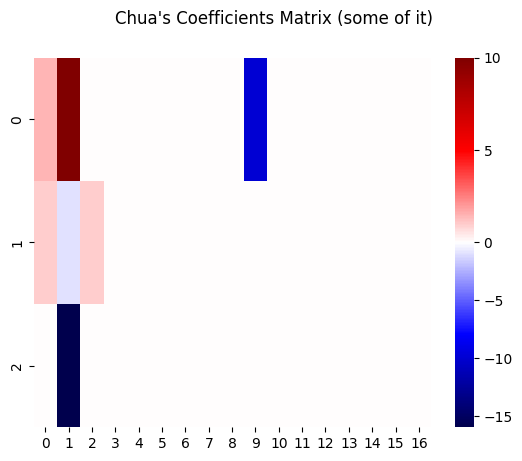

In [367]:
import seaborn as sns 
from matplotlib.colors import TwoSlopeNorm

norm_col = TwoSlopeNorm(
    vmin = chua_coef.min(),
    vmax = chua_coef.max(),
    vcenter = 0
)

sns.heatmap(chua_coef[:, :17], cmap="seismic", norm=norm_col)

plt.suptitle("Chua's Coefficients Matrix (some of it)")
plt.show()

In [346]:
features_processed = []
for feature in features:
    features_processed.append(f"${feature}$")

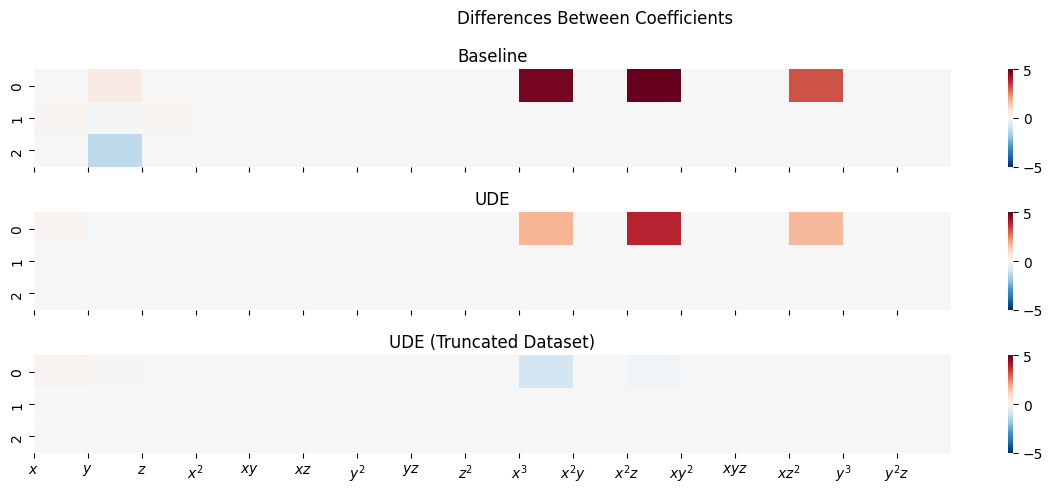

In [413]:
diff_mat_1 = chua_coef[:, :17]-sindy_baseline.optimizer.coef_[:, :17]
diff_mat_2 = chua_coef[:, :17]-sindy_ude.optimizer.coef_[:, :17]
diff_mat_3 = chua_coef[:, :17]-sindy_ude_alt.optimizer.coef_[:, :17]

max_1 = jnp.max(jnp.abs(jnp.array([diff_mat_1.min(), diff_mat_1.max()])))
max_2 = jnp.max(jnp.abs(jnp.array([diff_mat_2.min(), diff_mat_3.max()])))
max_3 = jnp.max(jnp.abs(jnp.array([diff_mat_2.min(), diff_mat_3.max()])))

norm_col = TwoSlopeNorm(
    vmin = -5,
    vmax = 5,
    vcenter = 0
)

fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

sns.heatmap(diff_mat_1, cmap="RdBu_r", norm=norm_col, ax=axes[0])
axes[0].set_title("Baseline")
axes[1].set_title("UDE")
axes[2].set_title("UDE (Truncated Dataset)")

sns.heatmap(diff_mat_2, cmap="RdBu_r", norm=norm_col, ax=axes[1])
sns.heatmap(diff_mat_3, cmap="RdBu_r", norm=norm_col, ax=axes[2])

plt.xticks(range(17), labels=features_processed[:17])
plt.suptitle("Differences Between Coefficients")
plt.tight_layout()
plt.show()

In [16]:
# Try to fix with ODE optimization (https://docs.kidger.site/optimistix/examples/optimise_diffeq/)

import optimistix as optx
# model calibration with optimization techniques
# calibrate the model with the best coefficients (according to MSE)

def identified_chua(t, xyz, args):
    a1, a2, a3, a4, b1, b2, b3, c1 = args
    x, y, z = xyz
    return jnp.array(
        [
            a1 * x + a2 * y + a3 * (x**3) + a4 * (x**2) * z,
            b1 * x + b2 * y + b3 * z,
            c1 * y,
        ]
    )


# Try to use a shorter time series first
x_train_reduced = x_train[:10]
t_train_reduced = t_train[:10]

@eqx.filter_jit
def residual(args, _):
    # solve
    term = dfx.ODETerm(identified_chua)
    solver = dfx.Tsit5()
    y0 = jnp.array((0.0001, 0.1, 0))

    # solve equation
    sol = dfx.diffeqsolve(
        term, solver, y0=y0, t0=t_train_reduced[0], t1=t_train_reduced[-1], saveat=dfx.SaveAt(ts=t_train_reduced), args=args, dt0=(t_train_reduced[1]-t_train_reduced[0]),
        adjoint=dfx.DirectAdjoint(),
    ).ys 
    
    return sol - x_train_reduced

initial_guess = jnp.array([1.302, 0.947, -9.084, 0.179, 1.003, -1.015, 1.003, -16.023])

residual_solver = optx.LevenbergMarquardt(rtol=1e-8, atol=1e-8, verbose=True)

fixed_params = optx.least_squares(residual, residual_solver, initial_guess, max_steps=10000)

Step: 0, Accepted steps: 0, Steps since acceptance: 0, Loss on this step: 0.7880449949388699, Loss on the last accepted step: 0.0, Step size: 1.0, y: [  1.302   0.947  -9.084   0.179   1.003  -1.015   1.003 -16.023], y on the last accepted step: [  1.302   0.947  -9.084   0.179   1.003  -1.015   1.003 -16.023]
Step: 1, Accepted steps: 1, Steps since acceptance: 0, Loss on this step: 0.4398765506862274, Loss on the last accepted step: 0.7880449949388699, Step size: 3.5, y: [  1.53694445   1.11417876  -9.08362239   0.17757961   1.07296358
  -1.10540841   0.75488959 -16.00222341], y on the last accepted step: [  1.53694445   1.11417876  -9.08362239   0.17757961   1.07296358
  -1.10540841   0.75488959 -16.00222341]
Step: 2, Accepted steps: 2, Steps since acceptance: 0, Loss on this step: 0.3421949363148495, Loss on the last accepted step: 0.4398765506862274, Step size: 3.5, y: [  1.5070781    1.33568157  -9.08618959   0.1761136    0.95068896
  -1.33954467   0.35266464 -15.95901226], y on t

In [17]:
fixed_params.value

Array([ 1.42999826e+00,  9.99957098e+00, -1.00009748e+01,  1.83684925e-03,
        9.99927081e-01, -9.99806299e-01,  9.99948709e-01, -1.59991653e+01],      dtype=float64)

In [18]:
# It worked! (kinda) Plot to believe
def fixed_chua(t, xyz, args):
    a1, a2, a3, a4, b1, b2, b3, c1 = fixed_params.value
    x, y, z = xyz
    return jnp.array(
        [
            a1 * x + a2 * y + a3 * (x**3) + a4 * (x**2) * z,
            b1 * x + b2 * y + b3 * z,
            c1 * y,
        ]
    )


In [19]:
# solve
term_fixed = dfx.ODETerm(fixed_chua)
solver = dfx.Tsit5()
y0 = jnp.array((0.0001, 0.1, 0))
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# solve equation
sol = dfx.diffeqsolve(
    term_fixed, solver, y0=y0, t0=0, t1=T_MAX, dt0=0.01, saveat=saveat, stepsize_controller=stepper
).ys 

# get original solution
sol_true = dfx.diffeqsolve(
    terms=term, solver=solver, y0=y0, t0=0, t1=T_MAX, dt0=0.01,saveat=saveat,stepsize_controller=stepper,
    args=(ALPHA, BETA, GAMMA, A, C)
).ys

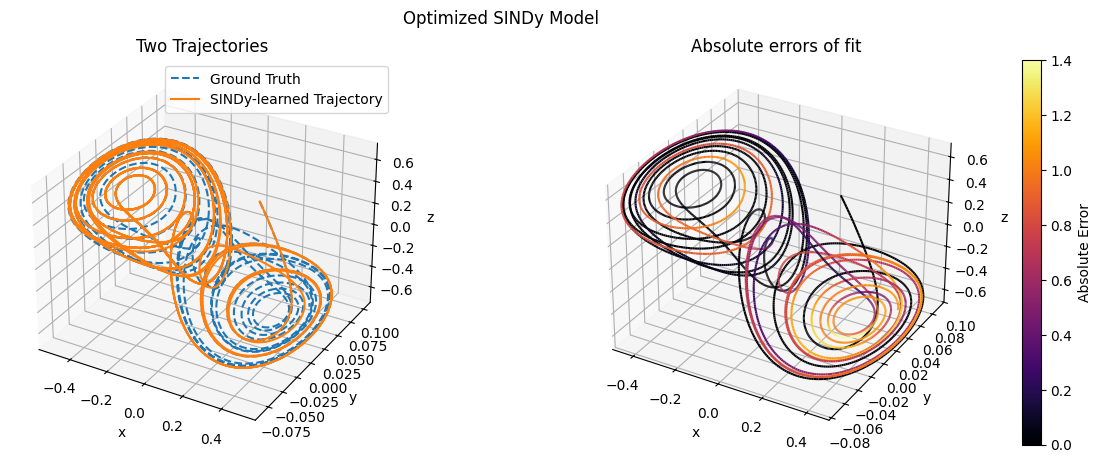

In [26]:
show_trajectory_results(sol_true, sol, "Optimized SINDy Model")

In [27]:
# Try to evaluate lyapunov coefficients (?)

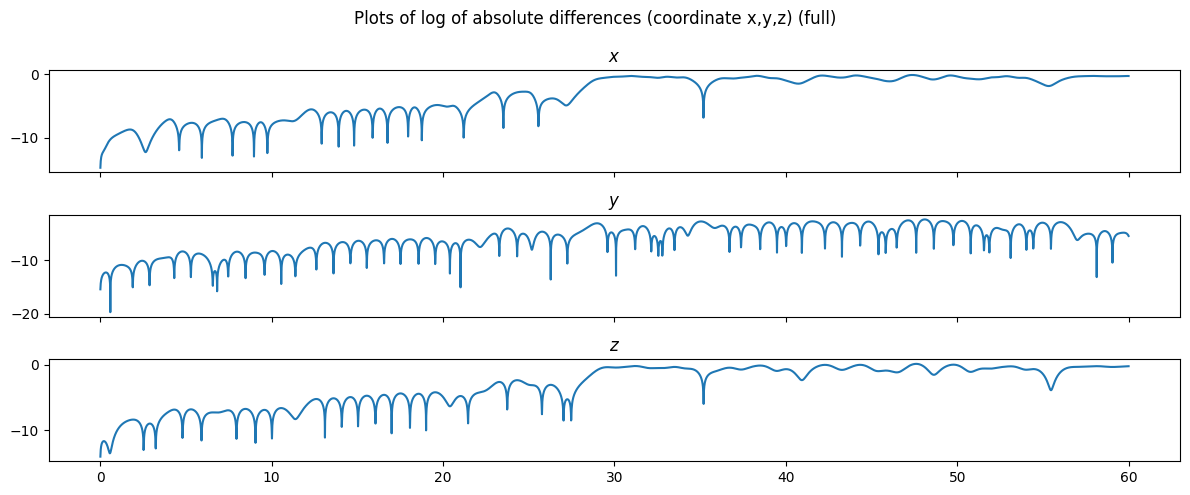

In [48]:
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

plt.suptitle("Plots of log of absolute differences (coordinate x,y,z) (full)")

plt.sca(axes[0])
plt.plot(t_eval[1:], diff_x := jnp.log(jnp.abs(sol[1:, 0] - sol_true[1:, 0])))
plt.title("$x$")
plt.sca(axes[1])
plt.plot(t_eval[1:], diff_y := jnp.log(jnp.abs(sol[1:, 1] - sol_true[1:, 1])))
plt.title("$y$")

plt.sca(axes[2])
plt.plot(t_eval[1:], diff_z := jnp.log(jnp.abs(sol[1:, 2] - sol_true[1:, 2])))
plt.title("$z$")

plt.tight_layout()

plt.show()


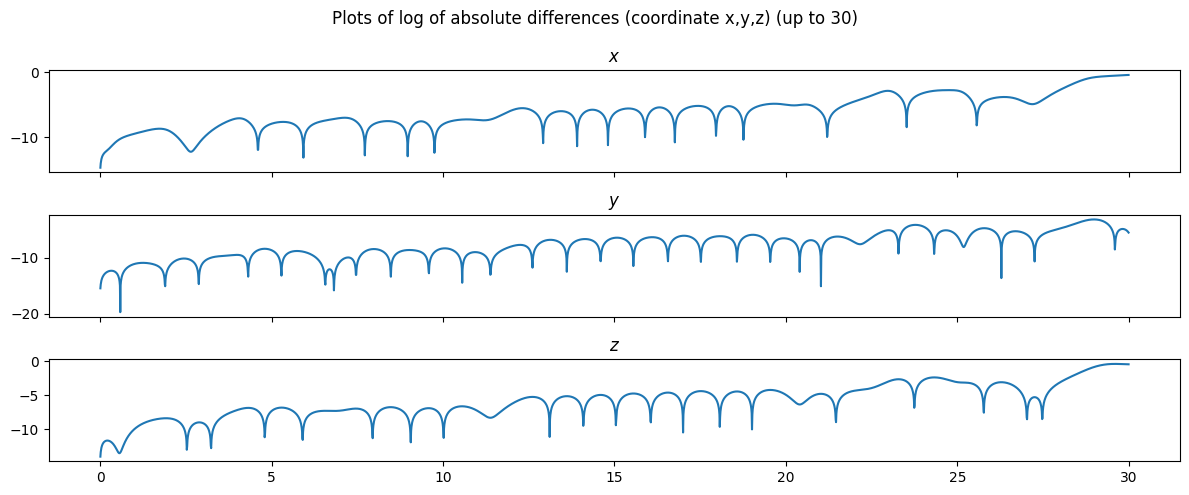

In [80]:
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

plt.suptitle("Plots of log of absolute differences (coordinate x,y,z) (up to 30)")

MAX = 3000

plt.sca(axes[0])
plt.plot(t_eval[1:MAX], diff_x := jnp.log(jnp.abs(sol[1:MAX, 0] - sol_true[1:MAX, 0])))
plt.title("$x$")
plt.sca(axes[1])
plt.plot(t_eval[1:MAX], diff_y := jnp.log(jnp.abs(sol[1:MAX, 1] - sol_true[1:MAX, 1])))
plt.title("$y$")

plt.sca(axes[2])
plt.plot(t_eval[1:MAX], diff_z := jnp.log(jnp.abs(sol[1:MAX, 2] - sol_true[1:MAX, 2])))
plt.title("$z$")

plt.tight_layout()

plt.show()


In [81]:
diff_x[2]

Array(-13.62721938, dtype=float64)

In [82]:
from sklearn.linear_model import LinearRegression
reg_x = LinearRegression(fit_intercept=False)
reg_y = LinearRegression(fit_intercept=False)
reg_z = LinearRegression(fit_intercept=False)

# manually modify intercept

reg_x.fit(t_eval[1:MAX].reshape(-1, 1), diff_x-diff_x[0]) # Fit on the zero-centered datasets
reg_y.fit(t_eval[1:MAX].reshape(-1, 1), diff_y-diff_x[1])
reg_z.fit(t_eval[1:MAX].reshape(-1, 1), diff_z-diff_x[2])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [83]:
print(f"ESTIMATED LLE COEFFICIENTS:\n\tx: {reg_x.coef_}\n\ty: {reg_y.coef_}\n\tz: {reg_z.coef_}")

ESTIMATED LLE COEFFICIENTS:
	x: [0.48948883]
	y: [0.36721533]
	z: [0.44949577]


In [84]:
predict_x = reg_x.predict(t_eval[1:MAX].reshape(-1, 1))+diff_x[0]
predict_y = reg_x.predict(t_eval[1:MAX].reshape(-1, 1))+diff_y[0]
predict_z = reg_x.predict(t_eval[1:MAX].reshape(-1, 1))+diff_z[0]


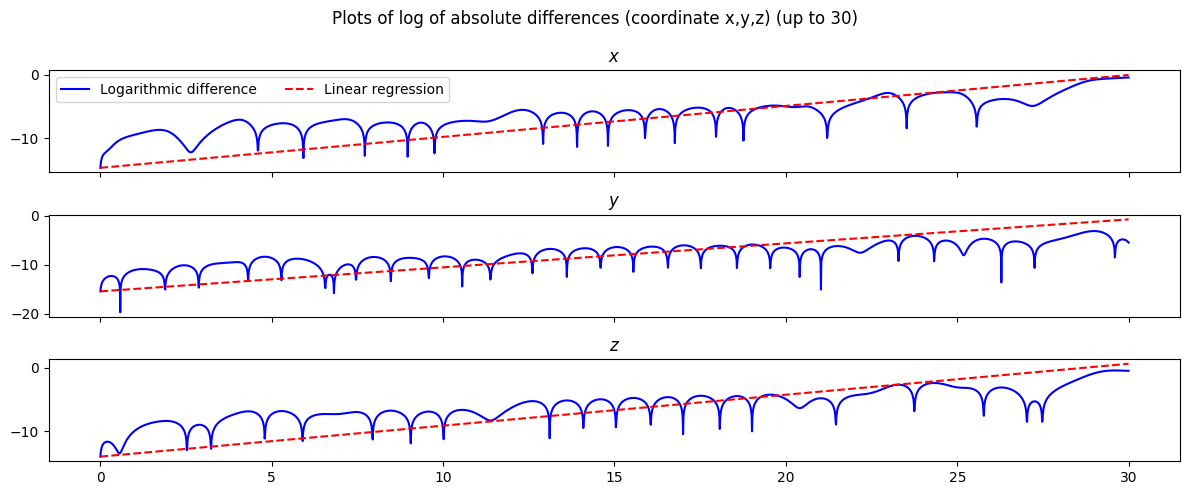

In [92]:
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

plt.suptitle("Plots of log of absolute differences (coordinate x,y,z) (up to 30)")

predicts = {
    0: predict_x,
    1: predict_y,
    2: predict_z
}

diffs = {
    0: diff_x, 
    1: diff_y, 
    2: diff_z
}

symbs = {
    0: '$x$',
    1: '$y$',
    2: '$z$'
}

plt.sca(axes[0])
plt.plot([], [], color="blue", label="Logarithmic difference")
plt.plot([], [], linestyle="--", color='red', label ="Linear regression")
plt.legend(ncol=2)

for i in range(3):
    plt.sca(axes[i])
    plt.plot(t_eval[1:MAX], diffs[i], color="blue")
    plt.plot(t_eval[1:MAX], predicts[i], linestyle="--", color='red')
    plt.title(symbs[i])

plt.tight_layout()

plt.show()


In [78]:
print(f"ESTIMATED LLE COEFFICIENTS:\n\tx: {reg_x.coef_}\n\ty: {reg_y.coef_}\n\tz: {reg_z.coef_}")

ESTIMATED LLE COEFFICIENTS:
	x: [0.48768215]
	y: [0.36065724]
	z: [0.44808668]
